**Dataset source**: https://www.kaggle.com/datasets/santanukundu/delhivery-dataset/data 

The dataset is about Delhivery's logistics operations in India. 

**Column description:**  

**data**: Test or training data.  
**trip_creation_time**: Timestamp of trip creation.  
**route_schedule_uuid**: Unique Id for a particular route schedule.  
**route_type**: Transportation type.   
**trip_uuid**: Unique ID given to a particular trip.    
**source_center**: Source ID of trip origin.  
**source_name**: Source Name of trip origin.  
**destination_center**: Destination ID of trip destination.  
**destination_name**: Destination Name of trip destination.  
**od_start_time**: Start time of this origin-destination (OD) leg of the trip.   
**od_end_time**: End time of this origin-destination (OD) leg of the trip.  
**is_cutoff**: True = still in transit (not yet delivered); False = this OD leg has been completed/delivered.   
**actual_distance_to_destination**: Actual distance between source and destination warehouse.    
**actual_time**: Cumulative actual time taken from the OD leg's start up to this scan point.   
**osrm_time**: OSRM-estimated time for this OD leg, as of this scan point.  
**osrm_distance**: OSRM-estimated shortest-path distance for this OD leg, as of this scan point.  
**segment_actual_time**: This is a segment time. Time taken by the subset of the package delivery.    
**segment_osrm_time**: This is the OSRM segment time. Time taken by the subset of the package delivery.    
**segment_osrm_distance**: This is the OSRM distance. Distance covered by subset of the package delivery.    

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib  
import holidays
import category_encoders as ce
from scipy.stats import skew

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from pathlib import Path

In [2]:

DATA_PATH = Path(r'C:\Users\danyl\Desktop\python\0 Projects\Delhivery Logistics Dataset\delhivery_data.csv')
MODEL_DIR = Path(r'C:\Users\danyl\Desktop\python\0 Projects\Delhivery Logistics Dataset\Model folder')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

data_df = pd.read_csv(DATA_PATH)  


In [3]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [4]:
data_df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


In [5]:
data_df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [6]:
# delete the rows where segment_actual_time is negative
data_df = data_df[data_df['segment_actual_time'] >= 0]

Find and fill in null values. Null values are in column source_name and destination_name. 

In [7]:
data_df.isnull().sum()

data                                0
trip_creation_time                  0
route_schedule_uuid                 0
route_type                          0
trip_uuid                           0
source_center                       0
source_name                       293
destination_center                  0
destination_name                  261
od_start_time                       0
od_end_time                         0
start_scan_to_end_scan              0
is_cutoff                           0
cutoff_factor                       0
cutoff_timestamp                    0
actual_distance_to_destination      0
actual_time                         0
osrm_time                           0
osrm_distance                       0
factor                              0
segment_actual_time                 0
segment_osrm_time                   0
segment_osrm_distance               0
segment_factor                      0
dtype: int64

In [8]:
data_df.fillna({'source_name':'unknown', 'destination_name':'unknown'}, inplace=True)
data_df.isnull().sum()

data                              0
trip_creation_time                0
route_schedule_uuid               0
route_type                        0
trip_uuid                         0
source_center                     0
source_name                       0
destination_center                0
destination_name                  0
od_start_time                     0
od_end_time                       0
start_scan_to_end_scan            0
is_cutoff                         0
cutoff_factor                     0
cutoff_timestamp                  0
actual_distance_to_destination    0
actual_time                       0
osrm_time                         0
osrm_distance                     0
factor                            0
segment_actual_time               0
segment_osrm_time                 0
segment_osrm_distance             0
segment_factor                    0
dtype: int64

**Goal**: Plot a pie chart of trip_uuid types.  

**Note**: Filter for unique trip_uuid values and remove duplicates, because single trip ID may correspond to several rows. 

**Conclusion**: 60.12% of the trips are of type Carting, and the remaining 39.88% are of type FTL.


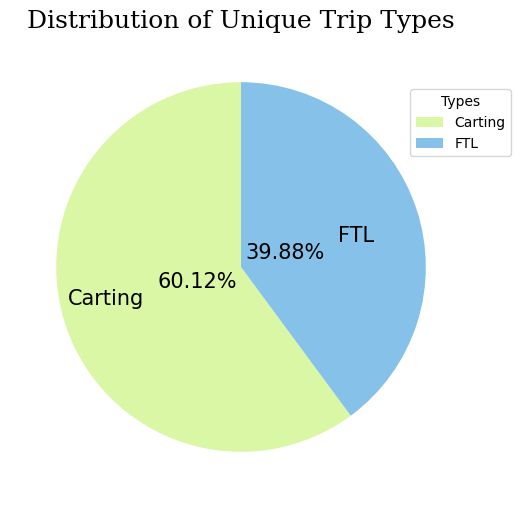

In [9]:
trip_type_df = data_df.drop_duplicates(subset=['trip_uuid'])[['route_type']]
trip_type_count = trip_type_df.value_counts()
unique_trip_type = trip_type_df['route_type'].unique()

font = {'family':'serif',
        'color': 'black',
        'weight': 'normal',
        'size': 18   
}

plt.figure(figsize=(6, 6))

patches, texts, autotexts = plt.pie(trip_type_count, labels=unique_trip_type, autopct='%1.2f%%', 
                                    colors=['#DAF7A6', '#85c1e9'], startangle=90, labeldistance=0.55, pctdistance=0.25)

plt.setp(texts, fontsize=15)
plt.setp(autotexts, fontsize=15)

plt.legend(title='Types', loc='upper right', bbox_to_anchor=(1, 0.9, 0.1, 0))

plt.title('Distribution of Unique Trip Types', fontdict=font)
plt.show()

**Goal**: Find the relationship between total actual distance and actual time taken for each trip. Each unique trip ID is considered as one trip.

**Note**: Calculate the actual time and distance from source to final destination for each trip ID by summing the actual times of all subsets of the package delivery. The actual time, where is_cutoff is FALSE, is the accumulated actual time of the delivery subset.  

**Conclusion**: The total actual distance from origin to destination and total atual time show a positive correlation, with a few trips located in the upper left corner being outliers, where the time taken is higher than the average.

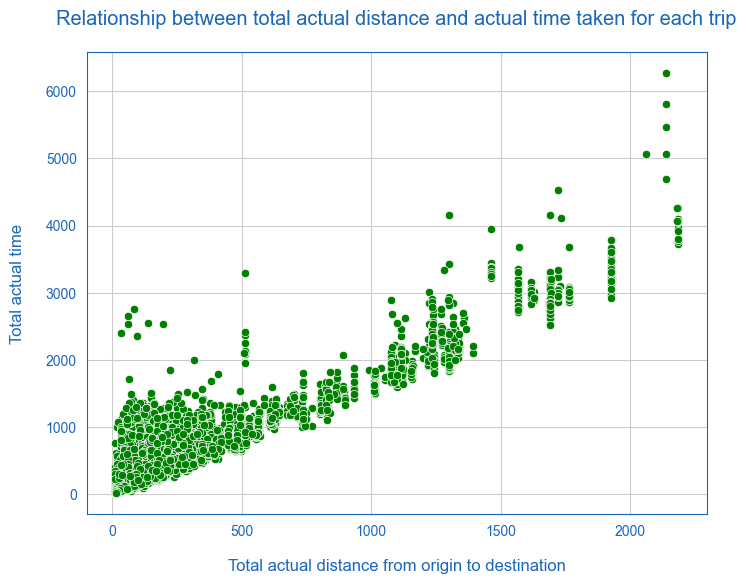

In [10]:
actual_time_df = data_df[data_df['is_cutoff']==False][['route_type','trip_uuid', 'is_cutoff', 'actual_distance_to_destination', 'actual_time']]
sum_columns = ['actual_distance_to_destination', 'actual_time']
first_columns = [col for col in actual_time_df.columns if col not in sum_columns and col!='trip_uuid']  

agg_dict = {col:'sum' for col in sum_columns}   # Apply 'sum' to 'actual_distance_to_destination' and 'actual_time'.
agg_dict.update({col:'first' for col in first_columns})   # Apply 'first' to other columns.

actual_time_df = actual_time_df.groupby(by='trip_uuid').agg(agg_dict).reset_index()
actual_time_df.rename(columns={'actual_distance_to_destination':'total_actual_distance_from_origin_to_destination', 'actual_time':'total_actual_time'}, inplace=True)

sns.set_style('whitegrid')
plt.figure(figsize=(8,6))
color = '#1a67b9'

sns.scatterplot(actual_time_df, x='total_actual_distance_from_origin_to_destination', y='total_actual_time', color='green')
plt.xlabel('Total actual distance from origin to destination', fontsize='large', color=color, labelpad=15)
plt.ylabel('Total actual time', fontsize='large', color=color, labelpad=15)
plt.title('Relationship between total actual distance and actual time taken for each trip', fontsize='x-large', color=color, pad=20)

ax = plt.gca()
for line in ['top', 'right', 'left', 'bottom']:
    ax.spines[line].set_color(color)
    
plt.tick_params(labelcolor=color)
plt.tick_params(color=color)
plt.show()


**Goal**: Find the top 10 shipping origins and destinations with the highest number of shipping trips and arrival trips. 

**Note**: Consider rows with the same trip ID but different origin and destination as one trip. Delete duplicate rows where the origin, destination, and trip ID are all the same, except for the last occurrence.

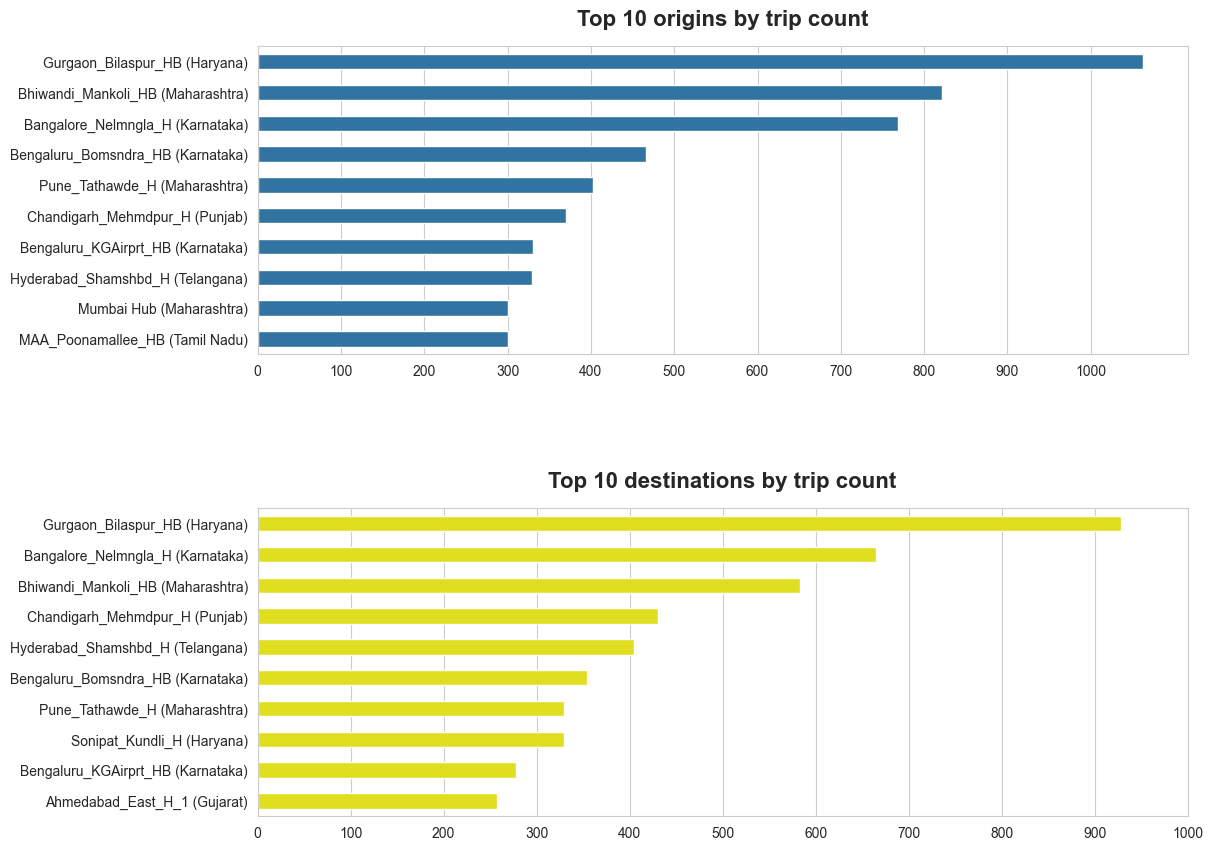

In [11]:
unique_df = data_df[['trip_uuid', 'source_name', 'destination_name']].drop_duplicates(subset=['trip_uuid', 'source_name', 'destination_name'], keep='last', ignore_index=True)
origin_count_top_10 = unique_df['source_name'].value_counts(ascending=False)[:10]
origin_count_top_10 = origin_count_top_10.reset_index()
destination_count_top_10 = unique_df['destination_name'].value_counts(ascending=False)[:10]
destination_count_top_10 = destination_count_top_10.reset_index()

plt.figure(figsize=(12,10))

plt.subplot(2,1,1)

sns.barplot(data=origin_count_top_10, x='count', y='source_name', width=0.5)
plt.xticks(np.arange(0, 1100, 100))
plt.ylabel('')
plt.xlabel('')
plt.title('Top 10 origins by trip count', fontsize=16, pad=15, weight='bold')

plt.subplot(2,1,2)
sns.set_style('whitegrid')
sns.barplot(data=destination_count_top_10, x='count', y='destination_name', width=0.5, color='yellow')
plt.xticks(np.arange(0, 1100, 100))
plt.ylabel('')
plt.xlabel('')
plt.title('Top 10 destinations by trip count',fontsize=16, pad=15, weight='bold')

plt.subplots_adjust(hspace=0.5)   # adjust the distance between 2 subplots

plt.show()


**Goal**: Find the distribution of the difference between the actual time and the time calculated by the engine time calculator ORSM for each package delivery.

**Note**: present the maximum value, minimum value, mean, 25th percentile, 75th percentile, and outliers using KDE plot, boxplot, and describe().    Due to the large gap between the maximum and minimum values, the box plot and KDE plot cannot clearly display the specific values of the maximum, minimum, mean, 25th percentile, and 75th percentile. In this case, it is more appropriate to use the describe() function to obtain these values.

       segment_actual_time  segment_osrm_time      time_diff
count        144846.000000      144846.000000  144846.000000
mean             36.207427          18.507304      17.700123
std              53.561259          14.775870      48.998105
min               0.000000           0.000000    -186.000000
25%              20.000000          11.000000       5.000000
50%              29.000000          17.000000      10.000000
75%              40.000000          22.000000      19.000000
max            3051.000000        1611.000000    2418.000000 



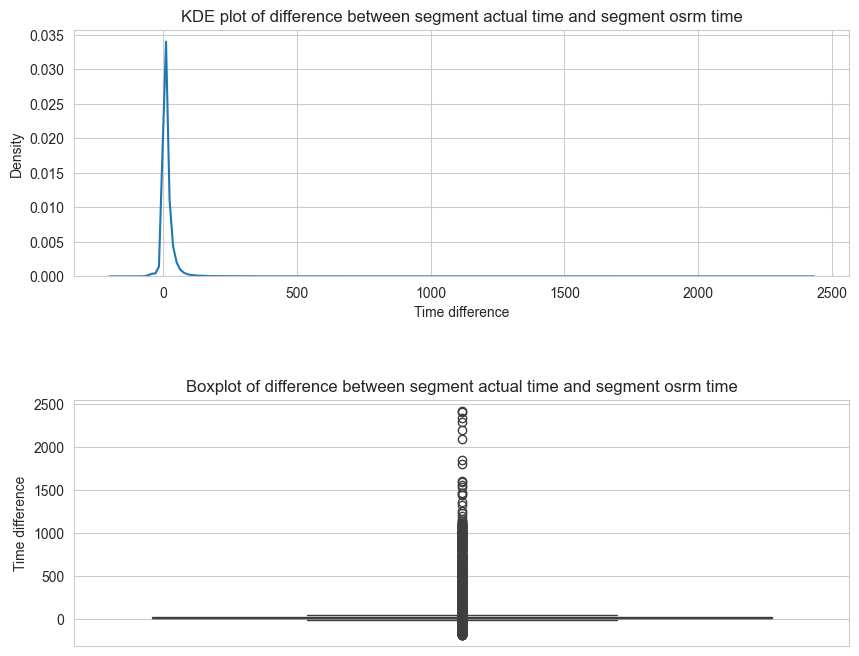

In [12]:
segment_time_df = data_df[['segment_actual_time','segment_osrm_time']]
segment_time_df = segment_time_df.copy()
segment_time_df['time_diff'] = segment_time_df['segment_actual_time'] - segment_time_df['segment_osrm_time']

print(segment_time_df.describe(), '\n')

plt.figure(figsize=(10,8))

plt.subplot(2,1,1)
sns.kdeplot(segment_time_df['time_diff'])
plt.xlabel('Time difference')
plt.title('KDE plot of difference between segment actual time and segment osrm time')

plt.subplot(2,1,2)
sns.boxplot(segment_time_df['time_diff'])
plt.ylabel('Time difference')
plt.title('Boxplot of difference between segment actual time and segment osrm time')

plt.subplots_adjust(hspace=0.5)

plt.show()

**Goal**: Predict actual delivery time.

**Steps**:
1. According to domain knowledge, trip type(route_type), origin(source_center), destination(destination_center), delivery start time(od_start_time), and actual delivery distance(actual_distance_to_destination) are selected as features. Since some values in source_name and destination_center and destination_name are unknown, select source_center and destination_center instead.
2. Keep only rows where is_cutoff is False, since their actual_time and actual_distance_to_destination are the accumulated time and distances of 1 trip between origin and destination.
3. Divide data into training set and testing set. 10-fold cross-validation is applied to get a more reliable estimate of generalization performance given the limited data size (each fold allocates 10% for testing, 90% for training). 
4. Skewness of actual_time and actual_distance_to_destination are 4.75 and 5.14 respectively, which means they are highly right-skewed. Thus, a transformation to reduce skewness is needed to reduce the influence of outliers.
5. Preprocess trans_actual_time into actual_time_scaled, and trans_actual_distance_to_destination into actual_distance_to_destination_scaled, both with Z-StandardScaler, to prevent features with different ranges from distorting the model. Target is actual_time_scaled. actual_distance_to_destination_scaled is a feature.
6. Split od_start_time into year, month, day, hour and determine if the day is an india holiday or weekday. Barplots 'Counts of month' and 'Counts of year' show that all deliveries are in September 2018 or October 2018. Thus, do not select year, month and day as features. 
7. Transform route_type into the numerical variable route_type_num. If route_type is Carting, then 1. If it is FTL, then 0.
8. Encode hour and day_of_week with Cyclic Encoding.
9. Encode source_center and destination_center with target encoding, because target encoding captures relationships between source_center or destination_center and actual_time.
10. Create Linear Regression, Decision Tree, Random Forest, Gradient Boosting, KNN, SVR and MLP Regressor models. Use mean squared error, mean absolute error, median absolute error and R-squared to evaluate the performance of predictive models. 

**Result**:

All models are strong (R² between 0.8125 and 0.8852). Random Forest performs the best, closely followed by Decision Tree and MLP Regressor. Linear Regression is the weakest. 
Across all models, MAE is higher than MedEA and the RMSE/MAE ratio is above the ~1.25 benchmark expected when errors are cleanly distributed. Therefore, a small subset of deliveries is disproportionately hard to predict, pulling up the average error for every model.

count of rows: 26118


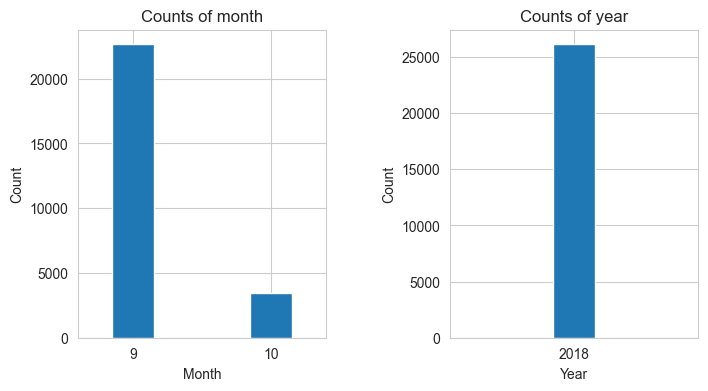

In [13]:
delivery_df = data_df[['route_type', 'trip_uuid', 'source_center', 'destination_center', 'od_start_time', 'actual_distance_to_destination', 'actual_time', 'is_cutoff']]
delivery_df = delivery_df[delivery_df['is_cutoff']==False]
delivery_df.reset_index(drop=True, inplace=True)

print('count of rows:', delivery_df['trip_uuid'].count())

# no na 
delivery_df.isnull().sum()

delivery_df['od_start_time'] = pd.to_datetime(delivery_df['od_start_time'])
delivery_df['year'] = delivery_df['od_start_time'].dt.year
delivery_df['month'] = delivery_df['od_start_time'].dt.month
delivery_df['day'] = delivery_df['od_start_time'].dt.day
delivery_df['date'] = delivery_df['od_start_time'].dt.date
delivery_df['day_of_week'] = delivery_df['od_start_time'].dt.weekday
delivery_df['hour'] = delivery_df['od_start_time'].dt.hour

month_counts = delivery_df['month'].value_counts()
year_counts = delivery_df['year'].value_counts()

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
month_counts.plot(kind='bar', width=0.3)
plt.title('Counts of month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1,2,2)
year_counts.plot(kind='bar', width=0.1)
plt.title('Counts of year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplots_adjust(wspace=0.5)
plt.show()


In [14]:

# calculate skewness
skewness_actual_time = skew(delivery_df['actual_time'])
print('skewness of actual_time: ', skewness_actual_time)

skewness_actual_distance_to_destination = skew(delivery_df['actual_distance_to_destination'])
print('skewness of actual_distance_to_destination: ', skewness_actual_distance_to_destination)

# apply log1p transformation to reduce skewness (both the target and the distance feature)
delivery_df['trans_actual_time'] = np.log1p(delivery_df['actual_time'])
delivery_df['trans_actual_distance_to_destination'] = np.log1p(delivery_df['actual_distance_to_destination'])

# transform route_type into a numerical variable. if route_type is Carting, then 1. If it is FTL, then 0.
delivery_df['route_type_num'] = delivery_df['route_type'].apply(lambda x: 1 if x=='Carting' else 0)

# if the day is not a weekday, then 1, else 0
delivery_df['is_weekend'] = delivery_df['day_of_week'].apply(lambda x: 1 if x>=5 else 0)

# if the day is a holiday, then 1, else 0
india_holidays = holidays.country_holidays('India')
delivery_df['is_holiday'] = delivery_df['date'].apply(lambda x: 1 if x in india_holidays else 0)

# Cyclic encoding only for variables with a periodic pattern: hour (rush-hour vs off-peak) and day_of_week (weekday vs weekend).
# month/day-of-month are dropped: the data only spans 2 months, and day-of-month has no clear behavioral cycle.
delivery_df['hour_sin'] = np.sin(2*np.pi*delivery_df['hour']/24)
delivery_df['hour_cos'] = np.cos(2*np.pi*delivery_df['hour']/24)
delivery_df['day_of_week_sin'] = np.sin(2*np.pi*delivery_df['day_of_week']/7)
delivery_df['day_of_week_cos'] = np.cos(2*np.pi*delivery_df['day_of_week']/7)



FEATURE_COLS = ['source_center', 'destination_center', 'trans_actual_distance_to_destination',
                 'route_type_num', 'is_weekend', 'is_holiday',
                 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos']

X = delivery_df[FEATURE_COLS]
y = delivery_df['trans_actual_time']

RANDOM_STATE = 42

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# intialize target encoding
target_encoder = ce.TargetEncoder(cols=['source_center', 'destination_center'])


models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, min_samples_split=10, min_samples_leaf=5,
                                            random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(max_depth=10, min_samples_leaf=5,
                                            random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(learning_rate=0.05, subsample=0.7, max_features='sqrt',
                                                    min_samples_split=10, min_samples_leaf=5,
                                                    random_state=RANDOM_STATE),  
    'KNN': KNeighborsRegressor(n_neighbors=10, weights='distance', n_jobs=-1),
    'SVR': SVR(C=0.5, epsilon=0.2, gamma=0.1),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(50, 30), alpha=0.01, max_iter=500,
                                   random_state=RANDOM_STATE)
}

results = []   

for model_name, model in models.items():
    fold_scores_dict = {'MSE':[], 'RMSE':[], 'MAE':[], 'MedAE':[], 'R2':[]}

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        time_scaler = StandardScaler()
        distance_scaler = StandardScaler()

        y_train = pd.Series(time_scaler.fit_transform(y_train.to_frame()).ravel(), index=y_train.index)
        y_test = pd.Series(time_scaler.transform(y_test.to_frame()).ravel(), index=y_test.index)

        X_train['trans_actual_distance_to_destination'] = distance_scaler.fit_transform(X_train[['trans_actual_distance_to_destination']])
        X_test['trans_actual_distance_to_destination'] = distance_scaler.transform(X_test[['trans_actual_distance_to_destination']])

        # apply target encoding to 'source_center', 'destination_center'
        target_encoder.fit(X_train[['source_center', 'destination_center']], y_train)
        X_train_encoded = target_encoder.transform(X_train[['source_center', 'destination_center']])
        X_test_encoded = target_encoder.transform(X_test[['source_center', 'destination_center']])

        X_train_encoded = pd.concat([X_train_encoded, X_train.drop(columns=['source_center', 'destination_center'])], axis=1)
        X_test_encoded = pd.concat([X_test_encoded, X_test.drop(columns=['source_center', 'destination_center'])], axis=1)

        model.fit(X_train_encoded, y_train)

        y_predict = model.predict(X_test_encoded)
        fold_mse = mean_squared_error(y_test, y_predict)

        fold_scores_dict['MSE'].append(fold_mse)
        fold_scores_dict['RMSE'].append(np.sqrt(fold_mse))   
        fold_scores_dict['MAE'].append(mean_absolute_error(y_test, y_predict))
        fold_scores_dict['MedAE'].append(median_absolute_error(y_test, y_predict))
        fold_scores_dict['R2'].append(r2_score(y_test, y_predict))

    average_mse = round(np.mean(fold_scores_dict['MSE']),4)
    average_rmse = round(np.mean(fold_scores_dict['RMSE']), 4)
    average_mae = round(np.mean(fold_scores_dict['MAE']),4)
    average_medae = round(np.mean(fold_scores_dict['MedAE']),4)
    average_r2 = round(np.mean(fold_scores_dict['R2']),4)

    results.append({'Model': model_name, 'MSE': average_mse, 'RMSE': average_rmse, 'MAE': average_mae,
                     'MedAE': average_medae, 'R2': average_r2})


results_df = pd.DataFrame(results).set_index('Model').sort_values('R2', ascending=False)
results_df


skewness of actual_time:  4.754749692742883
skewness of actual_distance_to_destination:  5.137805474709305


,MSE,RMSE,MAE,MedAE,R2
Model,,,,,
Random Forest,0.1146,0.3383,0.2278,0.1543,0.8852
Decision Tree,0.1306,0.3611,0.2420,0.1615,0.8692
MLP Regressor,0.1366,0.3693,0.2613,0.1899,0.8632
KNN,0.1556,0.3942,0.2750,0.1920,0.8442
Gradient Boosting,0.1601,0.4000,0.2880,0.2138,0.8396
SVR,0.1638,0.4044,0.2858,0.2093,0.8360
Linear Regression,0.1873,0.4326,0.3187,0.2519,0.8125


In [15]:
final_time_scaler = StandardScaler()
final_distance_scaler = StandardScaler()

y_scaled_full = pd.Series(final_time_scaler.fit_transform(y.to_frame()).ravel(), index=y.index)
X_scaled_full = X.copy()
X_scaled_full['trans_actual_distance_to_destination'] = final_distance_scaler.fit_transform(X_scaled_full[['trans_actual_distance_to_destination']])

final_target_encoder = ce.TargetEncoder(cols=['source_center', 'destination_center'])
X_encoded_full = final_target_encoder.fit_transform(X_scaled_full[['source_center', 'destination_center']], y_scaled_full)
X_encoded_full = pd.concat([X_encoded_full, X_scaled_full.drop(columns=['source_center', 'destination_center'])], axis=1)

for model_name, model in models.items():
    model.fit(X_encoded_full, y_scaled_full)
    joblib.dump(model, MODEL_DIR / f'{model_name}.pkl')

joblib.dump(final_target_encoder, MODEL_DIR / 'target_encoder.pkl')
joblib.dump(final_time_scaler, MODEL_DIR / 'time_scaler.pkl')
joblib.dump(final_distance_scaler, MODEL_DIR / 'distance_scaler.pkl')

print(f'Saved {len(models)} final models + encoder/scalers are saved')


Saved 7 final models + encoder/scalers are saved
